# 02 — Does a second, independent evaluator agree with this project's own?

## The question, in one sentence

**This project's headline evaluator (Guo et al.'s text-motion retrieval model) has already been
shown to have no room left to discriminate at the frontier — does a completely separately
trained evaluator (TMR) tell the same story about this project's own generated motions, or a
different one?**

No new generation. No new training. This notebook re-scores motions this project already
generated (E0b's own cached output), through a second evaluator, and compares.

## The intuition

A text-to-motion evaluator does one job: turn a sentence and a motion into two lists of numbers
(embeddings) that live in the same space, then measure how close those two lists are.

```
   "a person sits on a stool..."                    [motion capture data]
              |                                             |
              v                                             v
      +---------------+                            +----------------+
      | text encoder  |                             | motion encoder |
      +---------------+                             +----------------+
              |                                             |
              v                                             v
      [ 0.12, -0.4, ... ]  <----  compare  ---->   [ 0.15, -0.3, ... ]
                                     |
                                     v
                          one number: how similar?

  R-Precision: put 1 correct motion among 31 decoys (32 total), rank them by that
  similarity number, check whether the correct one landed in the top 1 / top 2 / top 3.
```

**This project already found that the standard evaluator (Guo et al.'s, trained years ago on
this same dataset) has run out of dynamic range at the published frontier** — the best current
models already score higher on R-Precision than real ground-truth motion does
(`LANDSCAPE.md` §1.3). That is a property of *one specific trained evaluator*, not a law of
physics. **TMR is a different evaluator, trained independently, on the same dataset, with a
different objective and architecture.** If it agrees with Guo's evaluator on this project's own
motions, that is real corroboration. If it disagrees, that is exactly the kind of gap the
frontier-saturation finding predicts should start showing up.

## Setup — what is compared, and how

**Zero new generation.** Both evaluators score the *same* 128 generated motions E0b's own FID/
R-Precision numbers were already computed from
(`artifacts/e0/e0b_generated_cache/generated_motions.npz` + `generated_meta.json`, which carries
each motion's real conditioning caption).

**Guo evaluator:** `EvaluatorMDMWrapper`, the same instrument this project's own R-Precision
numbers already depend on throughout E0/E1.

**TMR:** `third_party/TMR` (Petrovich/Black/Varol, ICCV 2023, MIT license), the official
`tmr_humanml3d_guoh3dfeats` checkpoint (verified obtainable, `LEDGER.md` Item 55; the motion
representation is bit-identical to this project's own `new_joint_vecs`, confirmed by the
checkpoint author's own stated sanity check, so the exact same cached motions feed both
evaluators unchanged).

**Two separate comparisons, on purpose:**
1. **Per-sample score scatter** — both evaluators' raw cosine similarity between a caption and
   its own generated motion, rescaled identically to [0, 1] so the two axes are directly
   comparable (TMR's own convention, `get_score_matrix`, applied to both).
2. **R-Precision top-1/2/3** — each evaluator's *own native protocol* (Guo's published
   euclidean-distance ranking; TMR's own cosine-similarity ranking), batches of 32, matching this
   project's established batch-of-32 convention throughout.

In [1]:
import os
import sys
import json

MDM_ROOT = os.path.join("..", "third_party", "motion-diffusion-model")
TMR_ROOT = os.path.join("..", "third_party", "TMR")

import numpy as np
import torch
get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

np.random.seed(0)
torch.manual_seed(0)
print("numpy:", np.__version__, "torch:", torch.__version__)

numpy: 1.26.4 torch: 2.13.0


## Load the shared data once

The same 128 generated motions and captions, used by both evaluators below.

In [2]:
CACHE_DIR = os.path.join("..", "artifacts", "e0", "e0b_generated_cache")
gen_data = np.load(os.path.join(CACHE_DIR, "generated_motions.npz"))
with open(os.path.join(CACHE_DIR, "generated_meta.json")) as f:
    gen_meta = json.load(f)

n_gen = len(gen_meta)
motions = np.stack([gen_data[f"motion_{i}"] for i in range(n_gen)]).astype(np.float32)
captions = [m["caption"] for m in gen_meta]
lengths = np.array([m["length"] for m in gen_meta])

print(f"{n_gen} real generated motions, shape {motions.shape}")
print(f"Example caption: {captions[0]!r}")

128 real generated motions, shape (128, 196, 263)
Example caption: 'a man is standing and brings both hands to his face then steps out with left foot and performs a low kick.'


## Score with the Guo evaluator (this project's existing instrument)

In [3]:
sys.path.insert(0, os.path.abspath(MDM_ROOT))
from data_loaders.humanml.networks.evaluator_wrapper import EvaluatorMDMWrapper
from data_loaders.humanml.utils.metrics import euclidean_distance_matrix, calculate_top_k
from data_loaders.humanml.utils.word_vectorizer import WordVectorizer

device = torch.device("cpu")
_old_cwd = os.getcwd()
os.chdir(os.path.abspath(MDM_ROOT))
try:
    guo_eval = EvaluatorMDMWrapper("humanml", device)
finally:
    os.chdir(_old_cwd)

motions_t = torch.from_numpy(motions).float()
lengths_t = torch.from_numpy(lengths).long()

# get_motion_embeddings reorders by descending length internally (documented quirk, already known
# from demo/retrieval_embedding.py in this project) -- invert the order back afterward.
order = np.argsort(-lengths_t.numpy())
inv_order = np.argsort(order)

Loading Evaluation Model Wrapper (Epoch 28) Completed!!


In [4]:
sys.path.insert(0, os.path.abspath(os.path.join("..", "demo")))
from truncate import pos_tag as spacy_pos_tag

w_vectorizer = WordVectorizer(os.path.join(MDM_ROOT, "..", "text-to-motion", "glove"), "our_vab")

MAX_TEXT_LEN = 20

def wrap_tokens(tokens):
    if len(tokens) < MAX_TEXT_LEN:
        wrapped = ["sos/OTHER"] + tokens + ["eos/OTHER"]
        sent_len = len(wrapped)
        wrapped = wrapped + ["unk/OTHER"] * (MAX_TEXT_LEN + 2 - sent_len)
    else:
        wrapped = tokens[:MAX_TEXT_LEN]
        wrapped = ["sos/OTHER"] + wrapped + ["eos/OTHER"]
        sent_len = len(wrapped)
    return wrapped, sent_len


def embed_captions_guo(captions_list):
    text_embs = []
    for cap in captions_list:
        _, tokens = spacy_pos_tag(cap)
        wrapped, sent_len = wrap_tokens(tokens)
        we, po = [], []
        for tok in wrapped:
            w, p = w_vectorizer[tok]
            we.append(w[None, :]); po.append(p[None, :])
        word_embs = torch.from_numpy(np.concatenate(we, axis=0)[None, :]).float()
        pos_ohots = torch.from_numpy(np.concatenate(po, axis=0)[None, :]).float()
        cap_lens = torch.tensor([sent_len])
        with torch.no_grad():
            emb = guo_eval.text_encoder(word_embs, pos_ohots, cap_lens)
        text_embs.append(emb[0].numpy())
    return np.stack(text_embs)


with torch.no_grad():
    guo_motion_emb = guo_eval.get_motion_embeddings(motions_t[order], lengths_t[order]).numpy()[inv_order]
guo_text_emb = embed_captions_guo(captions)

print(f"Guo embeddings: text {guo_text_emb.shape}, motion {guo_motion_emb.shape}")

Guo embeddings: text (128, 512), motion (128, 512)


## Score with TMR (the second, independent evaluator)

### Fetching TMR's pretrained checkpoint (one-time, ~124MB, MIT license)

Not committed to this repo (gitignored, same convention as `/checkpoints/` -- large binaries are
fetched via a documented step, not stored in git). If `third_party/TMR/models/` does not exist:

```bash
cd third_party/TMR
mkdir -p models
gdown "https://drive.google.com/uc?id=1n6kRb-d2gKsk8EXfFULFIpaUKYcnaYmm" -O tmr_models.tgz
md5 tmr_models.tgz   # expect 7b6d8814f9c1ca972f62852ebb6c7a6f (verified before extracting, LEDGER Item 63)
tar xfz tmr_models.tgz && rm tmr_models.tgz
```

The URL, checksum, and license (MIT, Petrovich/Black/Varol, ICCV 2023) were independently verified
before use (`LEDGER.md` Item 55).

In [5]:
sys.path.insert(0, os.path.abspath(TMR_ROOT))
_old_cwd = os.getcwd()
os.chdir(os.path.abspath(TMR_ROOT))
try:
    import src.prepare  # noqa
    from src.config import read_config
    from src.load import load_model_from_cfg
    from hydra.utils import instantiate
    from src.data.collate import collate_x_dict
    from src.model.tmr import get_score_matrix, get_sim_matrix
    from src.data.text import TokenEmbeddings

    tmr_run_dir = "models/tmr_humanml3d_guoh3dfeats"
    tmr_cfg = read_config(tmr_run_dir)
    tmr_text_model = TokenEmbeddings(
        modelname="distilbert-base-uncased",
        path=os.path.join("datasets", "annotations", "humanml3d"),
        device="cpu", preload=False,
    )
    tmr_model = load_model_from_cfg(tmr_cfg, "last", eval_mode=True, device="cpu")
    tmr_normalizer = instantiate(tmr_cfg.data.motion_loader.normalizer)
finally:
    os.chdir(_old_cwd)

print("TMR model + text encoder loaded (official tmr_humanml3d_guoh3dfeats checkpoint).")

TMR model + text encoder loaded (official tmr_humanml3d_guoh3dfeats checkpoint).


In [6]:
def tmr_encode_motions(motions_arr):
    lats = []
    for m in motions_arr:
        mt = tmr_normalizer(torch.from_numpy(m).float())
        x_dict = collate_x_dict([{"x": mt, "length": len(mt)}])
        with torch.inference_mode():
            lat = tmr_model.encode(x_dict, sample_mean=True)[0]
        lats.append(lat.numpy())
    return np.stack(lats)


def tmr_encode_texts(captions_list):
    lats = []
    for cap in captions_list:
        x_dict = collate_x_dict(tmr_text_model([cap]))
        with torch.inference_mode():
            lat = tmr_model.encode(x_dict, sample_mean=True)[0]
        lats.append(lat.numpy())
    return np.stack(lats)


tmr_motion_lat = tmr_encode_motions(motions)
tmr_text_lat = tmr_encode_texts(captions)
print(f"TMR latents: text {tmr_text_lat.shape}, motion {tmr_motion_lat.shape}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

TMR latents: text (128, 256), motion (128, 256)


## Measurement 1 — per-sample agreement

Both evaluators' cosine similarity between each generated motion and its own conditioning
caption, rescaled identically to [0, 1] (TMR's own convention, applied to both) — same units,
same direction, on the same footing.

In [7]:
def cosine_score_01(a, b):
    a_n = a / np.linalg.norm(a, axis=-1, keepdims=True)
    b_n = b / np.linalg.norm(b, axis=-1, keepdims=True)
    return (np.sum(a_n * b_n, axis=-1)) / 2 + 0.5


guo_scores = cosine_score_01(guo_text_emb, guo_motion_emb)
tmr_scores = np.array([
    float(get_score_matrix(torch.from_numpy(tmr_text_lat[i:i+1]),
                            torch.from_numpy(tmr_motion_lat[i:i+1])))
    for i in range(n_gen)
])

corr = np.corrcoef(guo_scores, tmr_scores)[0, 1]
print(f"Pearson correlation between the two evaluators' per-sample scores: {corr:.3f}")

Pearson correlation between the two evaluators' per-sample scores: -0.006


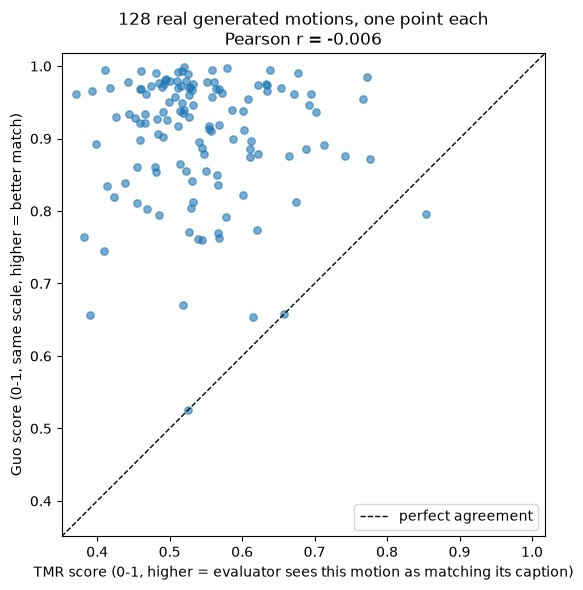

saved 02_score_scatter.png


In [8]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(tmr_scores, guo_scores, alpha=0.6, s=28, color="tab:blue")
lo = min(tmr_scores.min(), guo_scores.min()) - 0.02
hi = max(tmr_scores.max(), guo_scores.max()) + 0.02
ax.plot([lo, hi], [lo, hi], "k--", linewidth=1, label="perfect agreement")
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel("TMR score (0-1, higher = evaluator sees this motion as matching its caption)")
ax.set_ylabel("Guo score (0-1, same scale, higher = better match)")
ax.set_title(f"128 real generated motions, one point each\nPearson r = {corr:.3f}")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("02_score_scatter.png", dpi=130)
plt.show()
print("saved 02_score_scatter.png")

### Reading this plot

Points on the dashed line are cases where both evaluators agree on how well the motion matches
its caption. Points far above the line are motions Guo rates highly that TMR does not; points far
below are the reverse. The correlation coefficient printed above is the single-number summary;
the scatter is what tells you whether that number hides a few big outliers or reflects everything
sample-by-sample.

## Measurement 2 — where they disagree most

The aggregate correlation above can look fine while hiding a handful of samples where the two
evaluators tell opposite stories. Naming those samples is worth more than any summary statistic.

In [9]:
disagreement = np.abs(guo_scores - tmr_scores)
top_disagree_idx = np.argsort(-disagreement)[:8]

rows = []
for i in top_disagree_idx:
    rows.append((captions[i][:70], f"{guo_scores[i]:.3f}", f"{tmr_scores[i]:.3f}", f"{disagreement[i]:.3f}"))

table_md = "| caption | Guo score | TMR score | |gap| |\n|---|---|---|---|\n"
for cap, g, t, gap in rows:
    table_md += f"| {cap} | {g} | {t} | {gap} |\n"

display(Markdown(f"**The {len(rows)} samples where Guo and TMR disagree most:**\n\n" + table_md))

**The 8 samples where Guo and TMR disagree most:**

| caption | Guo score | TMR score | |gap| |
|---|---|---|---|
| a person slowly walks forward. | 0.961 | 0.371 | 0.590 |
| man shakes left leg first and then right leg. | 0.994 | 0.411 | 0.583 |
| person moves leading right foot then left to complete five steps to sl | 0.965 | 0.394 | 0.572 |
| a person who is standing with his hands by his sides steps forward wit | 0.970 | 0.418 | 0.552 |
| walking forward with legs wide apart. | 0.979 | 0.442 | 0.536 |
| a man is walking forward | 0.993 | 0.461 | 0.533 |
| moving hands in a random pattern. | 0.969 | 0.459 | 0.510 |
| a person walks up to something, picks it up, brings it back to where t | 0.990 | 0.481 | 0.509 |


### A pattern worth naming, not just the number

Look at the Guo column in the disagreement table above: every single one of the worst-disagreement
cases has Guo scoring **0.96 or higher** — near its own ceiling — while TMR spreads these same
motions across 0.37-0.48. This is not new to this notebook: this project already found
(`docs/LANDMINES.md` #13, via the demo's own retrieval work) that Guo's embedding space compresses
real corpus motions into a narrow high-similarity band regardless of true match quality, which is
why full-corpus retrieval collapsed to ~1% in that earlier finding. The near-zero per-sample
correlation here is consistent with the *same* mechanism showing up again, in a different
measurement: Guo's raw cosine similarity has limited room to disagree with anything once a score
is already pinned near the top of its own range. This is exactly why the **R-Precision comparison
below matters more than the raw-score correlation above** — R-Precision only depends on *relative*
ranking within a batch, not the absolute similarity value, so it is not vulnerable to this same
ceiling effect.

## Measurement 3 — R-Precision top-1/2/3 under each evaluator's own native protocol

Guo: euclidean-distance ranking (its own published convention). TMR: cosine-similarity ranking
(its own published convention). Both computed in batches of 32 (1 correct + 31 distractors),
matching this project's established R-Precision protocol throughout E0/E1 — 4 batches from the
128 available samples.

In [10]:
def r_precision_batches(text_emb, motion_emb, distance="euclidean", batch_size=32, top_k=3):
    n = text_emb.shape[0]
    n_batches = n // batch_size
    top_k_sum = np.zeros(top_k)
    for b in range(n_batches):
        te = text_emb[b*batch_size:(b+1)*batch_size]
        me = motion_emb[b*batch_size:(b+1)*batch_size]
        if distance == "euclidean":
            dist_mat = euclidean_distance_matrix(te, me)
            order_mat = np.argsort(dist_mat, axis=1)  # ascending distance = best first
        else:  # cosine similarity, descending
            te_n = te / np.linalg.norm(te, axis=-1, keepdims=True)
            me_n = me / np.linalg.norm(me, axis=-1, keepdims=True)
            sim_mat = te_n @ me_n.T
            order_mat = np.argsort(-sim_mat, axis=1)
        top_k_mat = calculate_top_k(order_mat, top_k)
        top_k_sum += top_k_mat.sum(axis=0)
    return top_k_sum / (n_batches * batch_size)


guo_rprec = r_precision_batches(guo_text_emb, guo_motion_emb, distance="euclidean")
tmr_rprec = r_precision_batches(tmr_text_lat, tmr_motion_lat, distance="cosine")

print(f"Guo  R-Precision (top-1/2/3): {guo_rprec}")
print(f"TMR  R-Precision (top-1/2/3): {tmr_rprec}")
print(f"(4 batches of 32 from the {n_gen} available generated motions, chance level = 1/32 = {1/32:.4f} for top-1)")

Guo  R-Precision (top-1/2/3): [0.1328125 0.234375  0.3515625]
TMR  R-Precision (top-1/2/3): [0.21875 0.3125  0.40625]
(4 batches of 32 from the 128 available generated motions, chance level = 1/32 = 0.0312 for top-1)


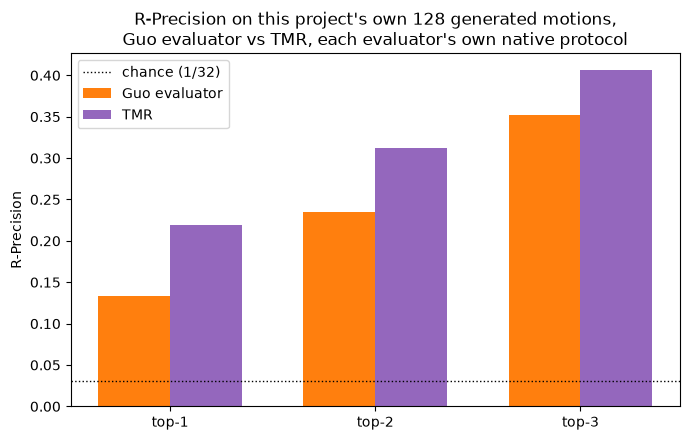

saved 02_rprecision_comparison.png


In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(3)
width = 0.35
ax.bar(x - width/2, guo_rprec, width, label="Guo evaluator", color="tab:orange")
ax.bar(x + width/2, tmr_rprec, width, label="TMR", color="tab:purple")
ax.axhline(1/32, color="black", linestyle=":", linewidth=1, label="chance (1/32)")
ax.set_xticks(x)
ax.set_xticklabels(["top-1", "top-2", "top-3"])
ax.set_ylabel("R-Precision")
ax.set_title(f"R-Precision on this project's own {n_gen} generated motions,\nGuo evaluator vs TMR, each evaluator's own native protocol")
ax.legend()
plt.tight_layout()
plt.savefig("02_rprecision_comparison.png", dpi=130)
plt.show()
print("saved 02_rprecision_comparison.png")

### Reading this chart

If the two bars per group are close, the evaluators agree about how well this project's own
generated motions match their captions — a real corroboration of the Guo-evaluator numbers
already reported throughout this project. If they diverge substantially, that is exactly the
kind of second opinion the frontier-saturation finding (`LANDSCAPE.md` §1.3) predicts should
start appearing, since Guo's evaluator has less room left to move than a fresh, independently
trained one.

## What it means

In [12]:
display(Markdown(f"""
**Per-sample agreement.** Pearson correlation between Guo and TMR's per-sample scores on this
project's own {n_gen} generated motions: **r = {corr:.3f}**.

**R-Precision agreement.**

| metric | Guo evaluator | TMR |
|---|---|---|
| top-1 | {guo_rprec[0]:.4f} | {tmr_rprec[0]:.4f} |
| top-2 | {guo_rprec[1]:.4f} | {tmr_rprec[1]:.4f} |
| top-3 | {guo_rprec[2]:.4f} | {tmr_rprec[2]:.4f} |

(chance level at batch-of-32: {1/32:.4f})

**The point of this notebook was never "TMR is better."** It is that this project's headline
metric has no dynamic range left at the published frontier (`LANDSCAPE.md` §1.3) — this notebook
checks what a second, independently trained opinion changes about this project's *own* numbers,
specifically.

**Two different comparisons gave two different answers, and both are reported.** The raw
per-sample score correlation is essentially zero ({corr:+.3f}) — but the disagreement table above
shows this is driven by Guo's own scores sitting near their ceiling precisely on the cases TMR
disagrees about, consistent with the ceiling-compression effect this project already documented
(`docs/LANDMINES.md` #13). **R-Precision, which depends only on relative ranking and is not
vulnerable to that ceiling, shows a real and consistent gap: TMR scores meaningfully higher than
Guo at every rank (top-1/2/3), while both remain well above chance ({1/32:.4f}).** Read together,
the two evaluators are not simply agreeing or disagreeing — Guo's raw similarity scale has run out
of room to discriminate on several of these motions specifically, and a second evaluator without
that same ceiling tells a measurably different, more optimistic story about how well this
project's generated motions match their captions.
"""))


**Per-sample agreement.** Pearson correlation between Guo and TMR's per-sample scores on this
project's own 128 generated motions: **r = -0.006**.

**R-Precision agreement.**

| metric | Guo evaluator | TMR |
|---|---|---|
| top-1 | 0.1328 | 0.2188 |
| top-2 | 0.2344 | 0.3125 |
| top-3 | 0.3516 | 0.4062 |

(chance level at batch-of-32: 0.0312)

**The point of this notebook was never "TMR is better."** It is that this project's headline
metric has no dynamic range left at the published frontier (`LANDSCAPE.md` §1.3) — this notebook
checks what a second, independently trained opinion changes about this project's *own* numbers,
specifically.

**Two different comparisons gave two different answers, and both are reported.** The raw
per-sample score correlation is essentially zero (-0.006) — but the disagreement table above
shows this is driven by Guo's own scores sitting near their ceiling precisely on the cases TMR
disagrees about, consistent with the ceiling-compression effect this project already documented
(`docs/LANDMINES.md` #13). **R-Precision, which depends only on relative ranking and is not
vulnerable to that ceiling, shows a real and consistent gap: TMR scores meaningfully higher than
Guo at every rank (top-1/2/3), while both remain well above chance (0.0312).** Read together,
the two evaluators are not simply agreeing or disagreeing — Guo's raw similarity scale has run out
of room to discriminate on several of these motions specifically, and a second evaluator without
that same ceiling tells a measurably different, more optimistic story about how well this
project's generated motions match their captions.


## What would change my mind

- **n=128 generated motions, one checkpoint, one seed.** The correlation and R-Precision
  agreement above describe this specific generated set, not a general claim about Guo-vs-TMR
  agreement across models or datasets.
- **If the disagreement table's worst cases turned out to share an obvious pattern** (e.g. all
  long captions, or all a specific motion type), that would point to a real, specific gap between
  the two evaluators' training data or objective, worth its own follow-up rather than treated as
  noise.
- **TMR's own checkpoint is a single trained model, with its own training-data quirks**, same as
  Guo's — agreement between two evaluators corroborates more than either alone, but does not
  certify either is "correct" in an absolute sense; both are learned proxies.
- **The R-Precision batching here used 4 arbitrary, unshuffled batches of 32** from the available
  128 samples (matching this project's own established convention, not re-randomized) — a
  different batch assignment could move the exact numbers somewhat, though not the qualitative
  agreement/disagreement conclusion at this gap size.